# 中国中老年人数据合并处理（改进版）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# ======================
# 第一步：合并所有6个文件（4+1模块 + 慢性病）
# ======================
print("="*60)
print("第一步：合并所有数据文件")
print("="*60)

file_paths = {
    "base": "./data/nl+xb.dta",
    "health": "./data/1deh.dta",
    "mental": "./data/2dsh.dta",
    "lifestyle": "./data/3dyh.dta",
    "social": "./data/4zhyh.dta"
}

# 1. 读取主表
print("正在读取主表：nl+xb.dta")
base_df = pd.read_stata(file_paths["base"], convert_categoricals=False)
base_df['age'] = 2020 - base_df['ba002_1']
base_df.rename(columns={'rgender': 'gender'}, inplace=True)
print(f"主表样本量：{len(base_df)}")

# 2. 合并四个子模块
modules = ["health", "mental", "lifestyle", "social"]
df = base_df.copy()
for module in modules:
    print(f"\n正在合并：{file_paths[module]}")
    module_df = pd.read_stata(file_paths[module], convert_categoricals=False)
    df = df.merge(module_df, on='ID', how='left')

# 3. 合并慢性病模块
print("\n正在合并慢性病模块：chronic.dta")
chronic_df = pd.read_stata("./data/chronic.dta", convert_categoricals=False)
df['ID'] = df['ID'].astype(str)
chronic_df['ID'] = chronic_df['ID'].astype(str)

# 只取共有ID
common_ids = list(set(df['ID']) & set(chronic_df['ID']))
print(f"  过滤前：主表{len(df)}行，慢性病{len(chronic_df)}行")
print(f"  共有ID：{len(common_ids)}个")
df = df[df['ID'].isin(common_ids)].reset_index(drop=True)
chronic_df = chronic_df[chronic_df['ID'].isin(common_ids)].reset_index(drop=True)

# 转换慢性病编码：1=患病→1，2=未患病→0，缺失→0
chronic_vars = [col for col in chronic_df.columns if col.startswith('da007_')]
print(f"  找到慢性病变量：{len(chronic_vars)}个")
for var in chronic_vars:
    chronic_df[var] = chronic_df[var].replace({1: 1, 2: 0}).fillna(0)
    chronic_df[var] = chronic_df[var].apply(lambda x: 0 if x not in [0, 1] else x)

# 合并慢性病到主表
df = df.merge(chronic_df[['ID'] + chronic_vars], on='ID', how='left')
for var in chronic_vars:
    df[var] = df[var].fillna(0)
df['chronic_count'] = df[chronic_vars].sum(axis=1)

print(f"\n✅ 全部合并完成！总样本量：{len(df)}，总变量数：{len(df.columns)}")
print(f"   平均患慢性病数量：{df['chronic_count'].mean():.2f}种")


第一步：合并所有数据文件
正在读取主表：nl+xb.dta
主表样本量：17705

正在合并：./data/1deh.dta

正在合并：./data/2dsh.dta

正在合并：./data/3dyh.dta

正在合并：./data/4zhyh.dta

正在合并慢性病模块：chronic.dta
  过滤前：主表17705行，慢性病17596行
  共有ID：17594个
  找到慢性病变量：14个

✅ 全部合并完成！总样本量：17594，总变量数：71
   平均患慢性病数量：1.36种


# ======================
# 第二步：数据过滤
# ======================

In [2]:
print("\n" + "="*60)
print("第二步：数据过滤")
print("="*60)

print(f"过滤前样本量：{len(df)}")

# 过滤45岁及以上
df = df[df['age'] >= 45].reset_index(drop=True)
print(f"过滤45岁以下后：{len(df)}行")

# 删除核心变量缺失
core_vars = ['ID', 'age', 'gender']
df = df.dropna(subset=core_vars).reset_index(drop=True)
print(f"删除核心变量缺失后：{len(df)}行")

# 过滤gender=0
df = df[df['gender'] != 0].reset_index(drop=True)
print(f"过滤gender=0后：{len(df)}行")

# 删除原始出生日期变量
for var in ['ba002_1', 'ba002_2', 'ba002_3']:
    if var in df.columns:
        df.drop(var, axis=1, inplace=True)

print(f"\n✅ 过滤完成，最终样本量：{len(df)}")



第二步：数据过滤
过滤前样本量：17594
过滤45岁以下后：17575行
删除核心变量缺失后：17563行
过滤gender=0后：17562行

✅ 过滤完成，最终样本量：17562


## ======================
## 第三步：探索性数据分析（EDA）
## ======================


第三步：探索性数据分析（EDA）

3.1 年龄分布直方图


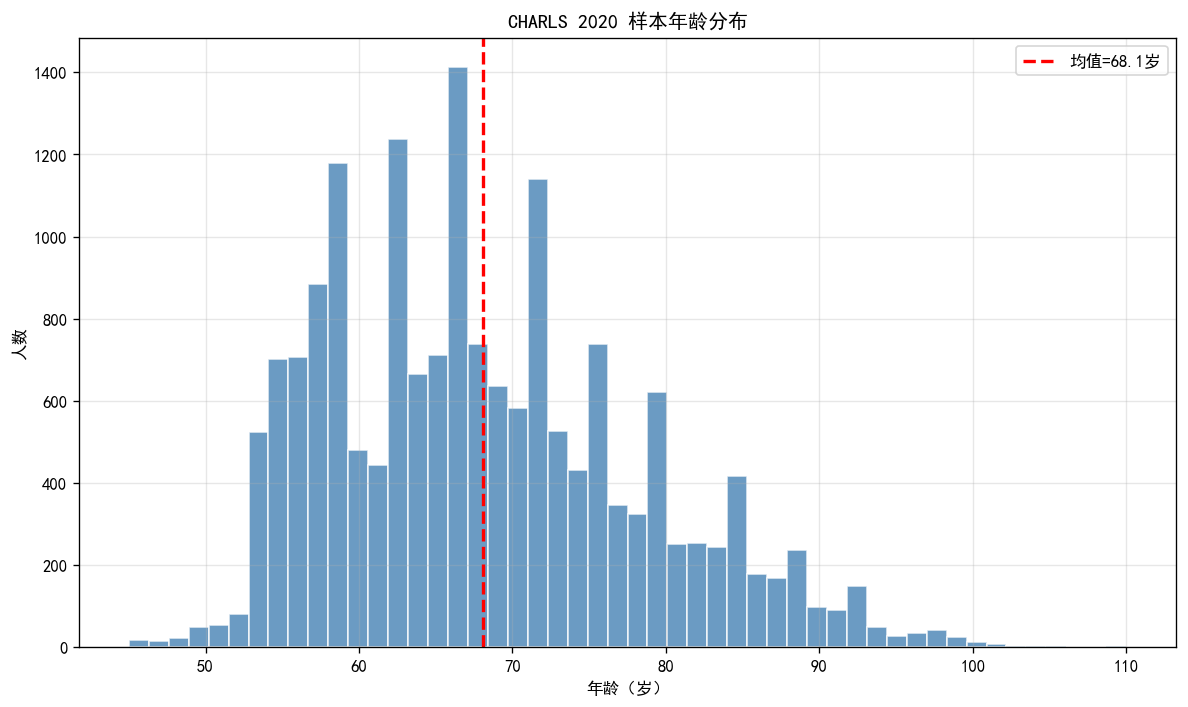


3.2 性别分布


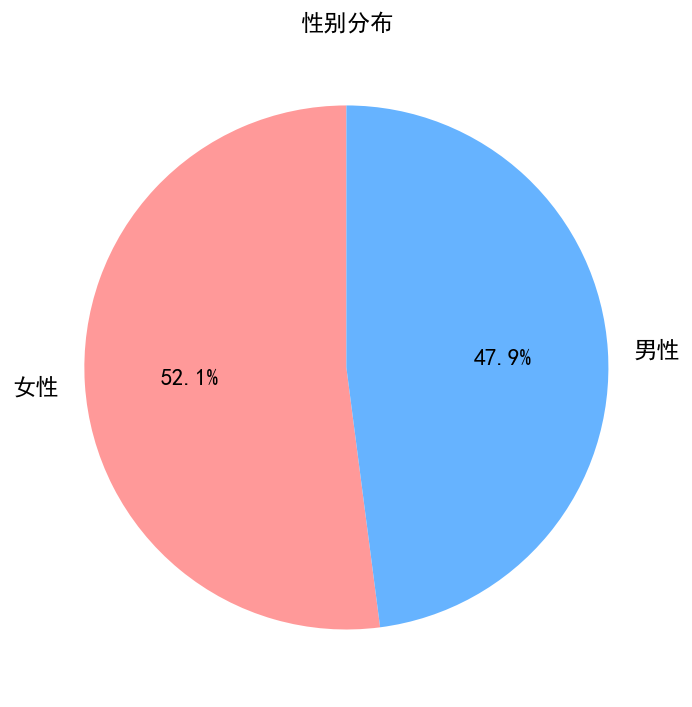


3.3 关键变量分布


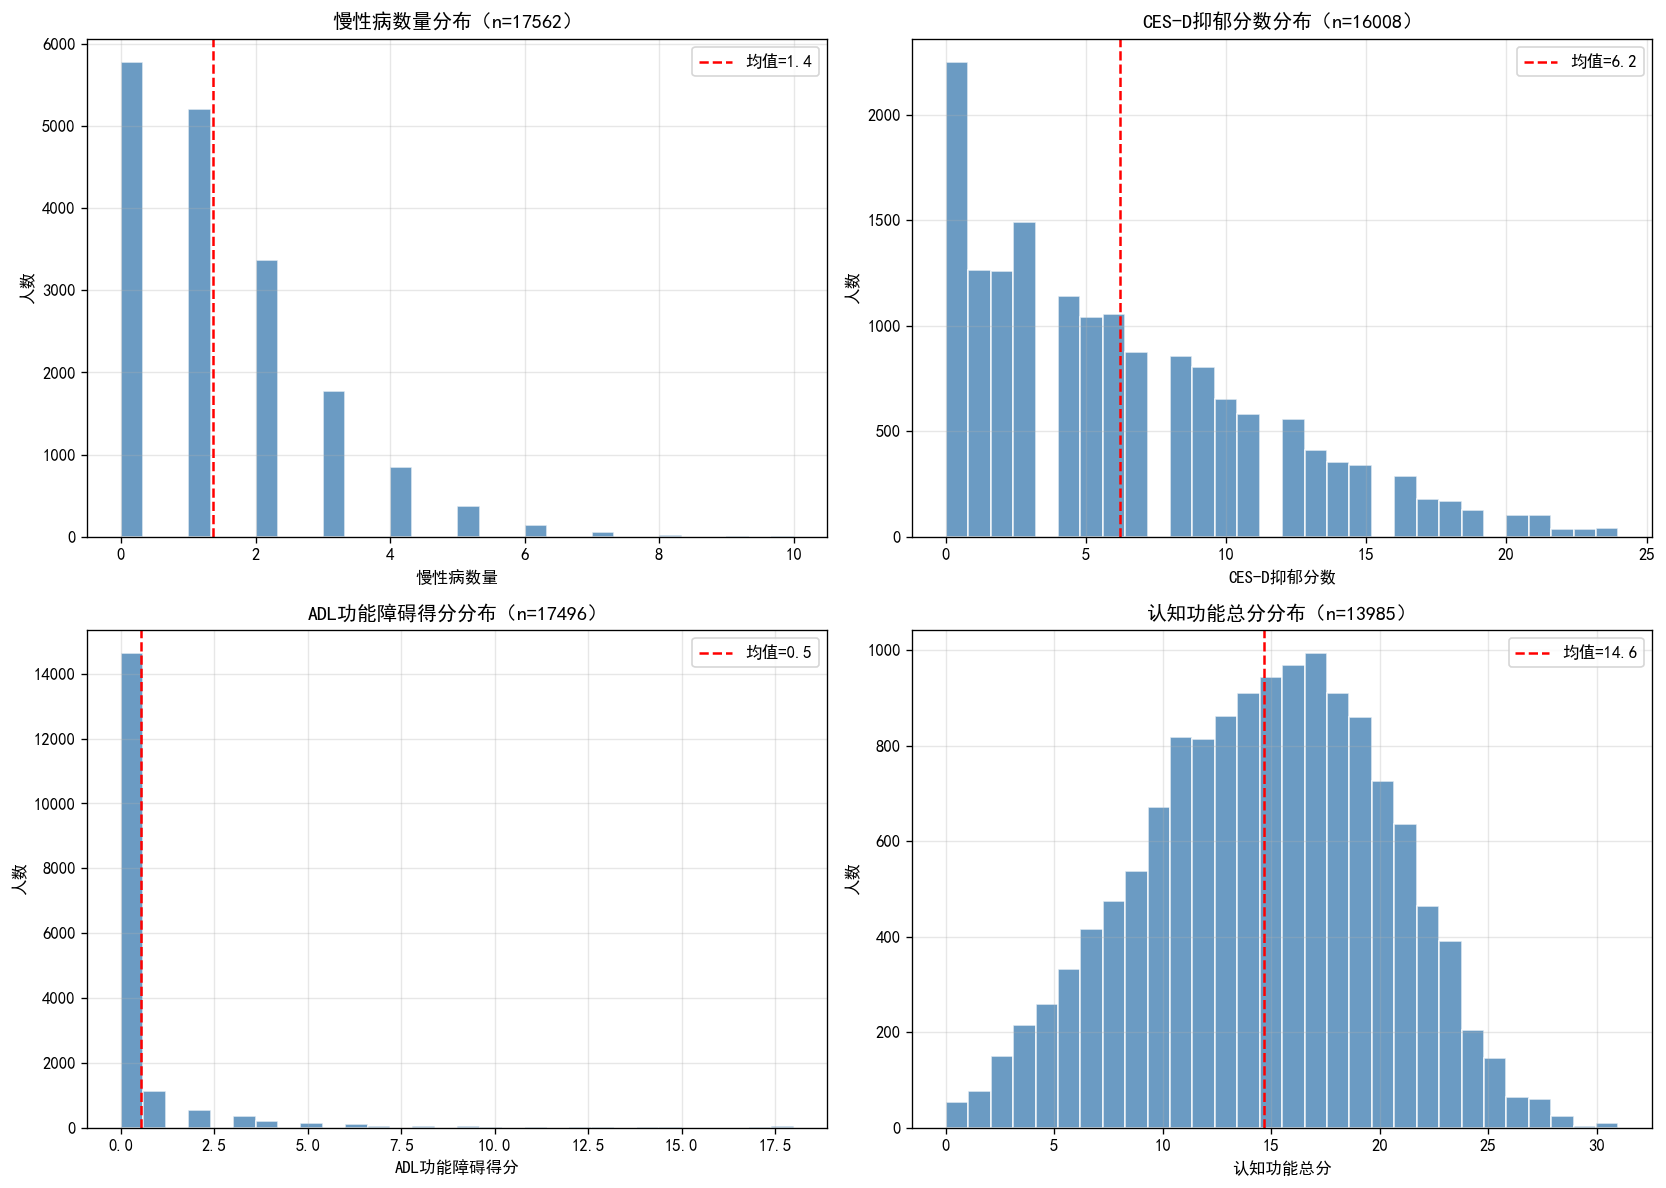


3.4 缺失率全面探查
缺失率 > 0 的变量：
smoke_cig_daily        73.505296
exer_walk_weekly       61.126295
exer_mod_weekly        60.927001
exer_vig_weekly        60.847284
exer_regular           60.790343
exer_total_min         60.682155
exer_standard          60.682155
exer_total_met         60.682155
child_notlive_freq     57.197358
child_contact_final    55.921877
child_high_contact     55.921877
child_coreside         55.921877
social_freq            53.997267
cognition_total        20.367840
memory_delay           19.957864
memory_immediate       19.268876
shmyd                  18.363512
cesd_depression         8.848650
cesd_score              8.848650
sleep_night             8.546863
vision_score            8.307710
sleep_nap               8.011616
social_any              7.789546
diet_irregular          7.789546
diet_meal_daily         7.789546
fall_2y                 7.698440
fracture_hip            7.687052
smoke_current           3.911855
smoke_status            3.911855
health_childhood 

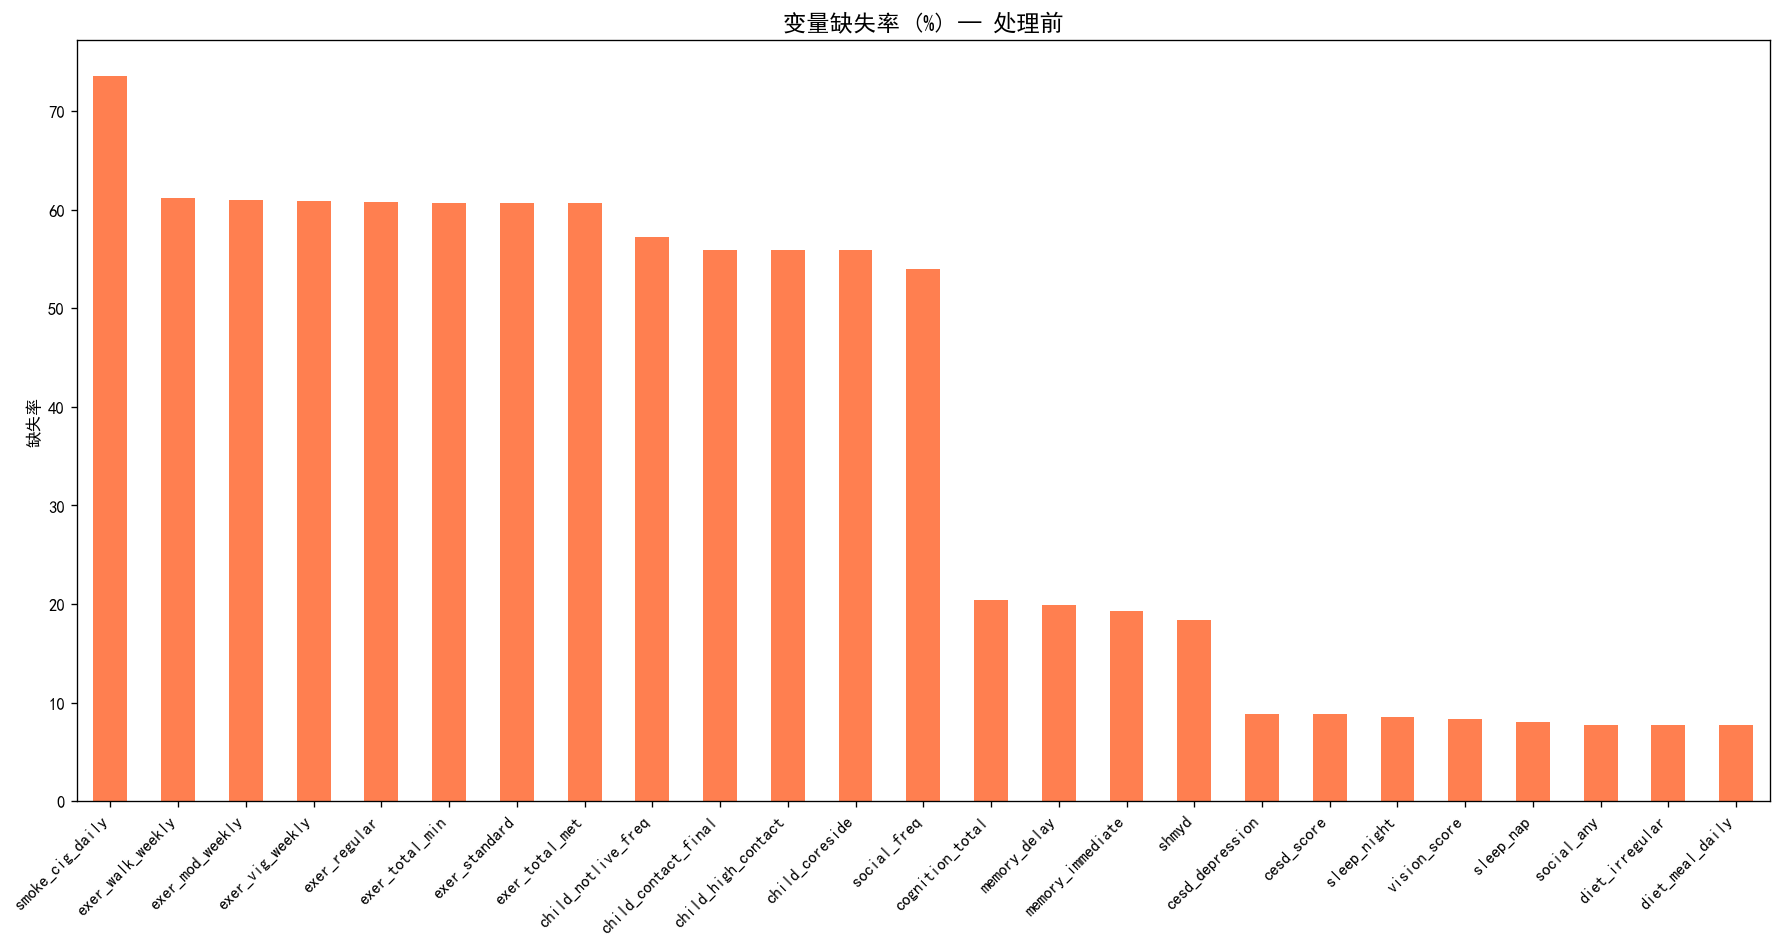


3.5 年龄-性别交叉分布
gender       女性    男性
age_group            
45-54       563   197
55-64      3294  3005
65-74      3129  3053
75-84      1440  1557
85+         716   608


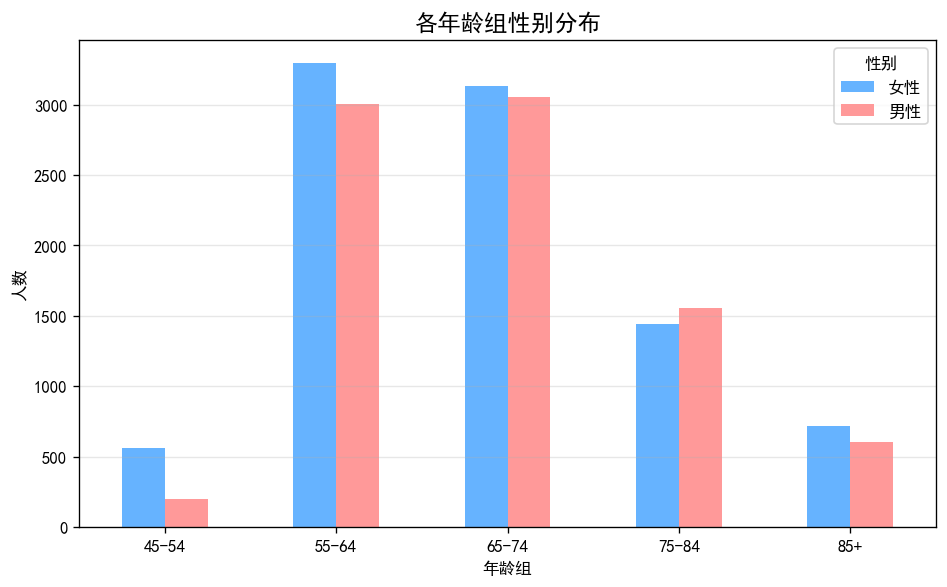


✅ EDA 完成！可以开始缺失值处理了。


In [3]:
print("\n" + "="*60)
print("第三步：探索性数据分析（EDA）")
print("="*60)

# --- 3.1 年龄分布直方图 ---
print("\n3.1 年龄分布直方图")
plt.figure(figsize=(10, 6))
plt.hist(df['age'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'均值={df["age"].mean():.1f}岁')
plt.xlabel('年龄（岁）')
plt.ylabel('人数')
plt.title('CHARLS 2020 样本年龄分布')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3.2 性别分布饼图 ---
print("\n3.2 性别分布")
gender_counts = df['gender'].value_counts()
gender_labels = ['女性', '男性']
gender_values = [gender_counts.get(2.0, 0), gender_counts.get(1.0, 0)]
plt.figure(figsize=(7, 6))
plt.pie(gender_values, labels=gender_labels, autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff'], startangle=90,
        textprops={'fontsize': 14})
plt.title('性别分布', fontsize=14)
plt.tight_layout()
plt.show()

# --- 3.3 关键变量分布直方图 ---
print("\n3.3 关键变量分布")
key_vars_for_plot = [
    ('chronic_count', '慢性病数量'),
    ('cesd_score', 'CES-D抑郁分数'),
    ('adl_score', 'ADL功能障碍得分'),
    ('cognition_total', '认知功能总分')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (var, label) in enumerate(key_vars_for_plot):
    if var in df.columns:
        ax = axes[idx]
        data = df[var].dropna()
        ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
        ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'均值={data.mean():.1f}')
        ax.set_xlabel(label)
        ax.set_ylabel('人数')
        ax.set_title(f'{label}分布（n={len(data)}）')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 3.4 缺失率柱状图 ---
print("\n3.4 缺失率全面探查")
missing_rate = df.isnull().mean().sort_values(ascending=False) * 100
missing_positive = missing_rate[missing_rate > 0]

print("缺失率 > 0 的变量：")
print(missing_positive)

if len(missing_positive) > 0:
    plt.figure(figsize=(15, 8))
    missing_positive.head(25).plot(kind='bar', color='coral')
    plt.title('变量缺失率 (%) — 处理前', fontsize=14)
    plt.ylabel('缺失率')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("✅ 无缺失值！")

# --- 3.5 年龄-性别交叉分布 ---
print("\n3.5 年龄-性别交叉分布")
age_bins = [45, 55, 65, 75, 85, 120]
age_labels = ['45-54', '55-64', '65-74', '75-84', '85+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

age_gender = pd.crosstab(df['age_group'], df['gender'].map({1: '男性', 2: '女性'}))
print(age_gender)

age_gender.plot(kind='bar', figsize=(8, 5), color=['#66b3ff', '#ff9999'])
plt.title('各年龄组性别分布', fontsize=14)
plt.xlabel('年龄组')
plt.ylabel('人数')
plt.xticks(rotation=0)
plt.legend(title='性别')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n✅ EDA 完成！可以开始缺失值处理了。")


# ======================
# 第四步：分类型处理缺失值
# ======================

In [4]:
print("\n" + "="*60)
print("第四步：处理缺失值")
print("="*60)

# 4.0 类型转换
for col in df.columns:
    if isinstance(df[col].dtype, pd.CategoricalDtype):
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass

# 4.1 跳题缺失（50%-74%）→ 填0
print("\n4.1 跳题缺失变量（缺失=0）...")

# 吸烟
if 'smoke_cig_daily' in df.columns:
    df['smoke_cig_daily'] = df['smoke_cig_daily'].fillna(0)
# 锻炼
for var in ['exer_walk_weekly', 'exer_mod_weekly', 'exer_vig_weekly',
            'exer_regular', 'exer_standard', 'exer_total_min', 'exer_total_met']:
    if var in df.columns:
        df[var] = df[var].fillna(0)
# 子女联系
for var in ['child_notlive_freq', 'child_coreside', 'child_contact_final', 'child_high_contact']:
    if var in df.columns:
        df[var] = df[var].fillna(0)
# 社交频率
if 'social_freq' in df.columns:
    df['social_freq'] = df['social_freq'].fillna(0)
print("  ✅ 跳题缺失变量处理完成")

# 4.2 中等缺失（10%-30%）→ 按年龄+性别分组中位数
print("\n4.2 中等缺失变量（分组中位数）...")
for var in ['cognition_total', 'memory_delay', 'memory_immediate',
            'cognition_orientation', 'cognition_executive', 'shmyd']:
    if var in df.columns:
        df[var] = df.groupby(['gender', 'age_group'])[var].transform(
            lambda x: x.fillna(x.median()))
print("  ✅ 中等缺失变量处理完成")

# 4.3 低缺失（1%-10%）→ 按年龄+性别分组填充
print("\n4.3 低缺失变量（分组填充）...")
for var in ['cesd_score', 'adl_score', 'vision_score', 'hearing_score',
            'srh', 'sleep_night', 'sleep_nap', 'pain_site_count']:
    if var in df.columns:
        df[var] = df.groupby(['gender', 'age_group'])[var].transform(
            lambda x: x.fillna(x.median()))

for var in ['cesd_depression', 'diet_irregular', 'diet_meal_daily', 'social_any',
            'smoke_status', 'smoke_current', 'drink_regular', 'drink_status',
            'fall_2y', 'fracture_hip', 'hearing_impair', 'dual_sensory_impair',
            'iadl_disability', 'vision_impair', 'adl_impair', 'adl_disability',
            'sleep_group', 'community_part']:
    if var in df.columns:
        df[var] = df.groupby(['gender', 'age_group'])[var].transform(
            lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0))
print("  ✅ 低缺失变量处理完成")

# 4.4 极低缺失（<3%）
print("\n4.4 极低缺失变量...")
if 'pain_any' in df.columns:
    df['pain_any'] = df['pain_any'].fillna(df['pain_any'].mode()[0])
for var in ['health_childhood', 'pain_level_x', 'pain_level_y']:
    if var in df.columns:
        df[var] = df[var].fillna(df[var].median())

# 4.5 合并重复疼痛变量
if 'pain_level_x' in df.columns and 'pain_level_y' in df.columns:
    df['pain_level'] = df[['pain_level_x', 'pain_level_y']].mean(axis=1)
    df.drop(['pain_level_x', 'pain_level_y'], axis=1, inplace=True)
    print("  ✅ 合并重复疼痛变量")

# 删除无用变量
if '_merge' in df.columns:
    df.drop('_merge', axis=1, inplace=True)


第四步：处理缺失值

4.1 跳题缺失变量（缺失=0）...
  ✅ 跳题缺失变量处理完成

4.2 中等缺失变量（分组中位数）...
  ✅ 中等缺失变量处理完成

4.3 低缺失变量（分组填充）...
  ✅ 低缺失变量处理完成

4.4 极低缺失变量...
  ✅ 合并重复疼痛变量


# 最终验证

In [5]:
print("\n" + "="*60)
print("缺失值处理完成！验证结果")
print("="*60)
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) == 0:
    print("✅ 完美！所有缺失值已处理！")
else:
    print("⚠️  仍有缺失：")
    print(remaining)

print(f"\n关键变量验证：")
print(f"  ADL总分：均值={df['adl_score'].mean():.2f}")
print(f"  CES-D抑郁：均值={df['cesd_score'].mean():.2f}")
print(f"  自评健康：均值={df['srh'].mean():.2f}")
print(f"  慢性病数量：均值={df['chronic_count'].mean():.2f}")

# 删除年龄组临时变量（聚类不需要）
if 'age_group' in df.columns:
    df.drop('age_group', axis=1, inplace=True)




缺失值处理完成！验证结果
✅ 完美！所有缺失值已处理！

关键变量验证：
  ADL总分：均值=0.54
  CES-D抑郁：均值=6.10
  自评健康：均值=1.99
  慢性病数量：均值=1.36


# 保存

In [7]:
df.to_csv("./data/charls_intermediate_updated.csv", index=False, encoding='utf-8-sig')
print(f"\n✅ 数据已保存：./data/charls_intermediate_updated.csv")
print(f"   大小：{len(df)}行 × {len(df.columns)}列")
print("\n 数据预处理全部完成！")


✅ 数据已保存：./data/charls_intermediate_updated.csv
   大小：17562行 × 66列

 数据预处理全部完成！
